# 07 — Feature Ablation: Model Comparison

Compares all 8 ablation runs across two model types and four feature configurations:

| Suffix | Description |
|---|---|
| `base` | No surface geometry features (baseline) |
| `norm_curv` | Query node features: surface normal + mean curvature |
| `multi` | All-aggregator message passing (mean + sum + max) |
| `both` | Query features + all-aggregator |

**Sections:**
1. Configuration
2. Training curves
3. Error distributions
4. Metrics comparison (sparse + full-mesh)
5. Per-protein consistency (heatmap + rank table)

In [10]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid."""
    available = [r for r in runs if (r["plot_dir"] / filename).exists()]
    if not available:
        print(f"No '{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(run["plot_dir"] / filename))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title_prefix):
    """1-row x 2-col grouped bar chart: one chart per model type."""
    if df.empty:
        print("No data to plot.")
        return
    metrics = [("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")]
    model_types = ["Attention", "Distance"]
    fig, axes = plt.subplots(1, len(model_types), figsize=(14, 5), sharey=False)
    fig.suptitle(title_prefix, fontsize=13, fontweight="bold")
    n_metrics = len(metrics)
    total_width = 0.7
    bar_w = total_width / n_metrics
    for ax, model_type in zip(axes, model_types):
        sub = df[df["Model"] == model_type].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        x = range(len(sub))
        for i, (metric, color) in enumerate(metrics):
            if metric not in sub.columns or sub[metric].isna().all():
                continue
            offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
            bars = ax.bar(offsets, sub[metric], width=bar_w, color=color, label=metric, zorder=3)
            ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
        ax.set_title(model_type, fontsize=12)
        ax.set_xlabel("Feature config")
        ax.set_xticks(list(x))
        ax.set_xticklabels(sub["Features"].tolist(), fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [11]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

RUNS = [
    dict(label="Attention — base",       model_type="attention", suffix="base",
         plot_dir=EVAL_ROOT/"attention_base",      ckpt_dir=CKPT_ROOT/"attention_base"),
    dict(label="Attention — norm + curv", model_type="attention", suffix="norm_curv",
         plot_dir=EVAL_ROOT/"attention_norm_curv", ckpt_dir=CKPT_ROOT/"attention_norm_curv"),
    dict(label="Attention — multi-agg",  model_type="attention", suffix="multi",
         plot_dir=EVAL_ROOT/"attention_multi",     ckpt_dir=CKPT_ROOT/"attention_multi"),
    dict(label="Attention — both",        model_type="attention", suffix="both",
         plot_dir=EVAL_ROOT/"attention_both",      ckpt_dir=CKPT_ROOT/"attention_both"),
    dict(label="Distance — base",         model_type="distance",  suffix="base",
         plot_dir=EVAL_ROOT/"distance_base",       ckpt_dir=CKPT_ROOT/"distance_base"),
    dict(label="Distance — norm + curv",  model_type="distance",  suffix="norm_curv",
         plot_dir=EVAL_ROOT/"distance_norm_curv",  ckpt_dir=CKPT_ROOT/"distance_norm_curv"),
    dict(label="Distance — multi-agg",   model_type="distance",  suffix="multi",
         plot_dir=EVAL_ROOT/"distance_multi",      ckpt_dir=CKPT_ROOT/"distance_multi"),
    dict(label="Distance — both",         model_type="distance",  suffix="both",
         plot_dir=EVAL_ROOT/"distance_both",       ckpt_dir=CKPT_ROOT/"distance_both"),
]

print(f"{'Run':<28}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 48)
for r in RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    print(f"{r['label']:<28}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                            Plots   Metrics
------------------------------------------------
Attention — base                 yes       yes
Attention — norm + curv          yes       yes
Attention — multi-agg            yes       yes
Attention — both                 yes       yes
Distance — base                  yes       yes
Distance — norm + curv           yes       yes
Distance — multi-agg             yes       yes
Distance — both                  yes       yes


## 2. Training Curves

Plots saved by `scripts/analyze_model.py --curves` for each run.

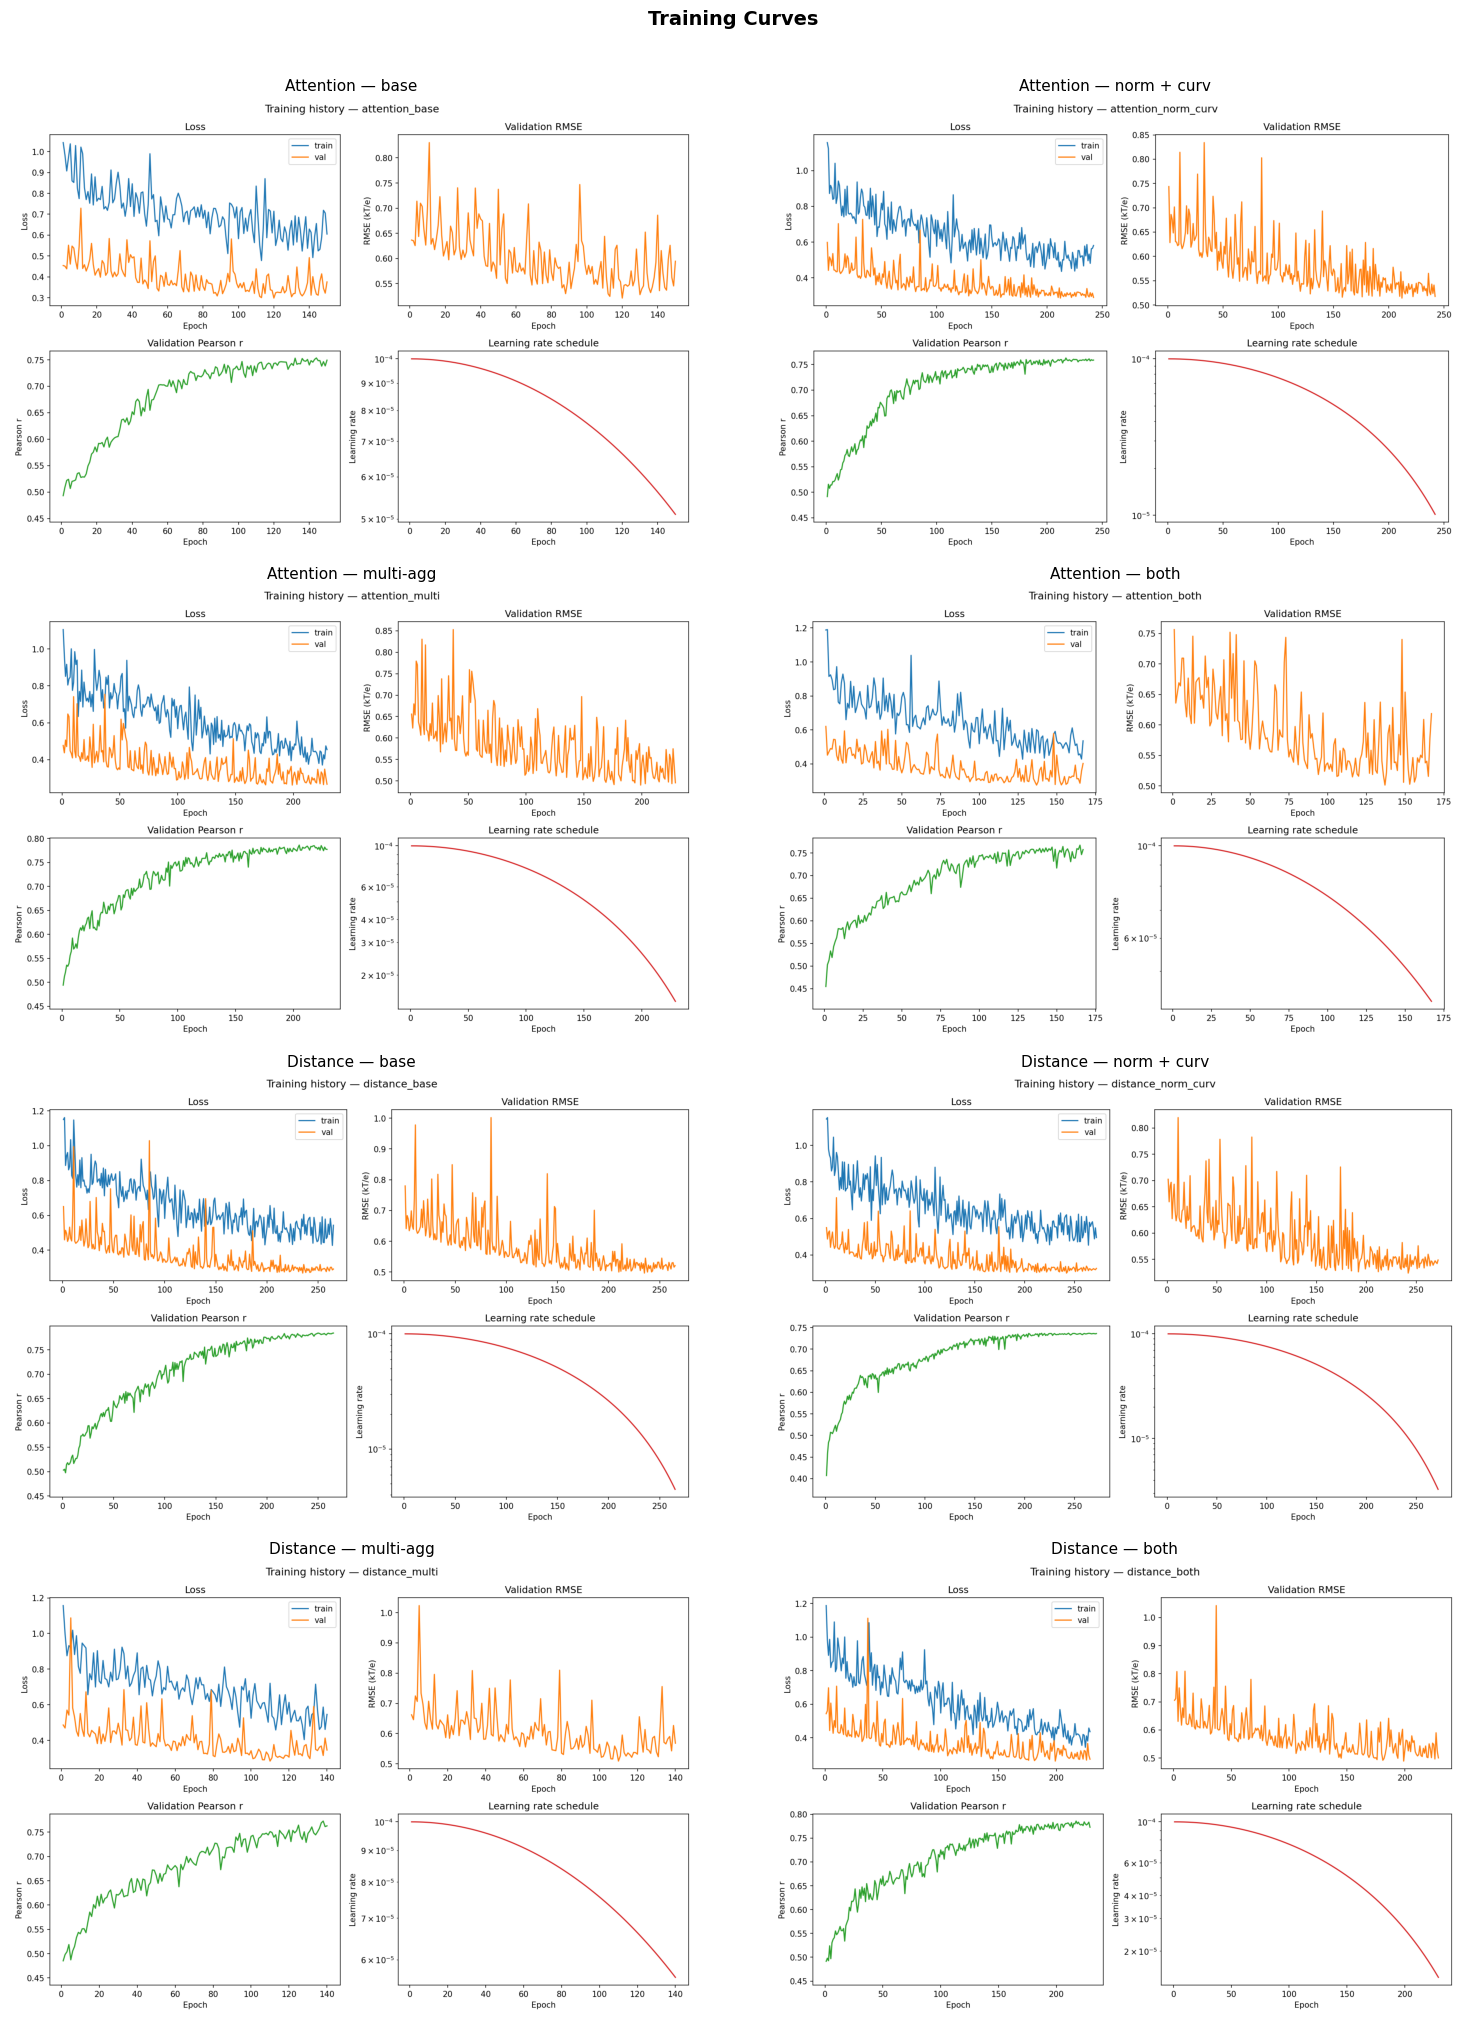

In [12]:
show_png_grid(RUNS, "training_curves.png", "Training Curves")

## 3. Error Distributions

Plots saved by `scripts/analyze_model.py --distributions` for each run.

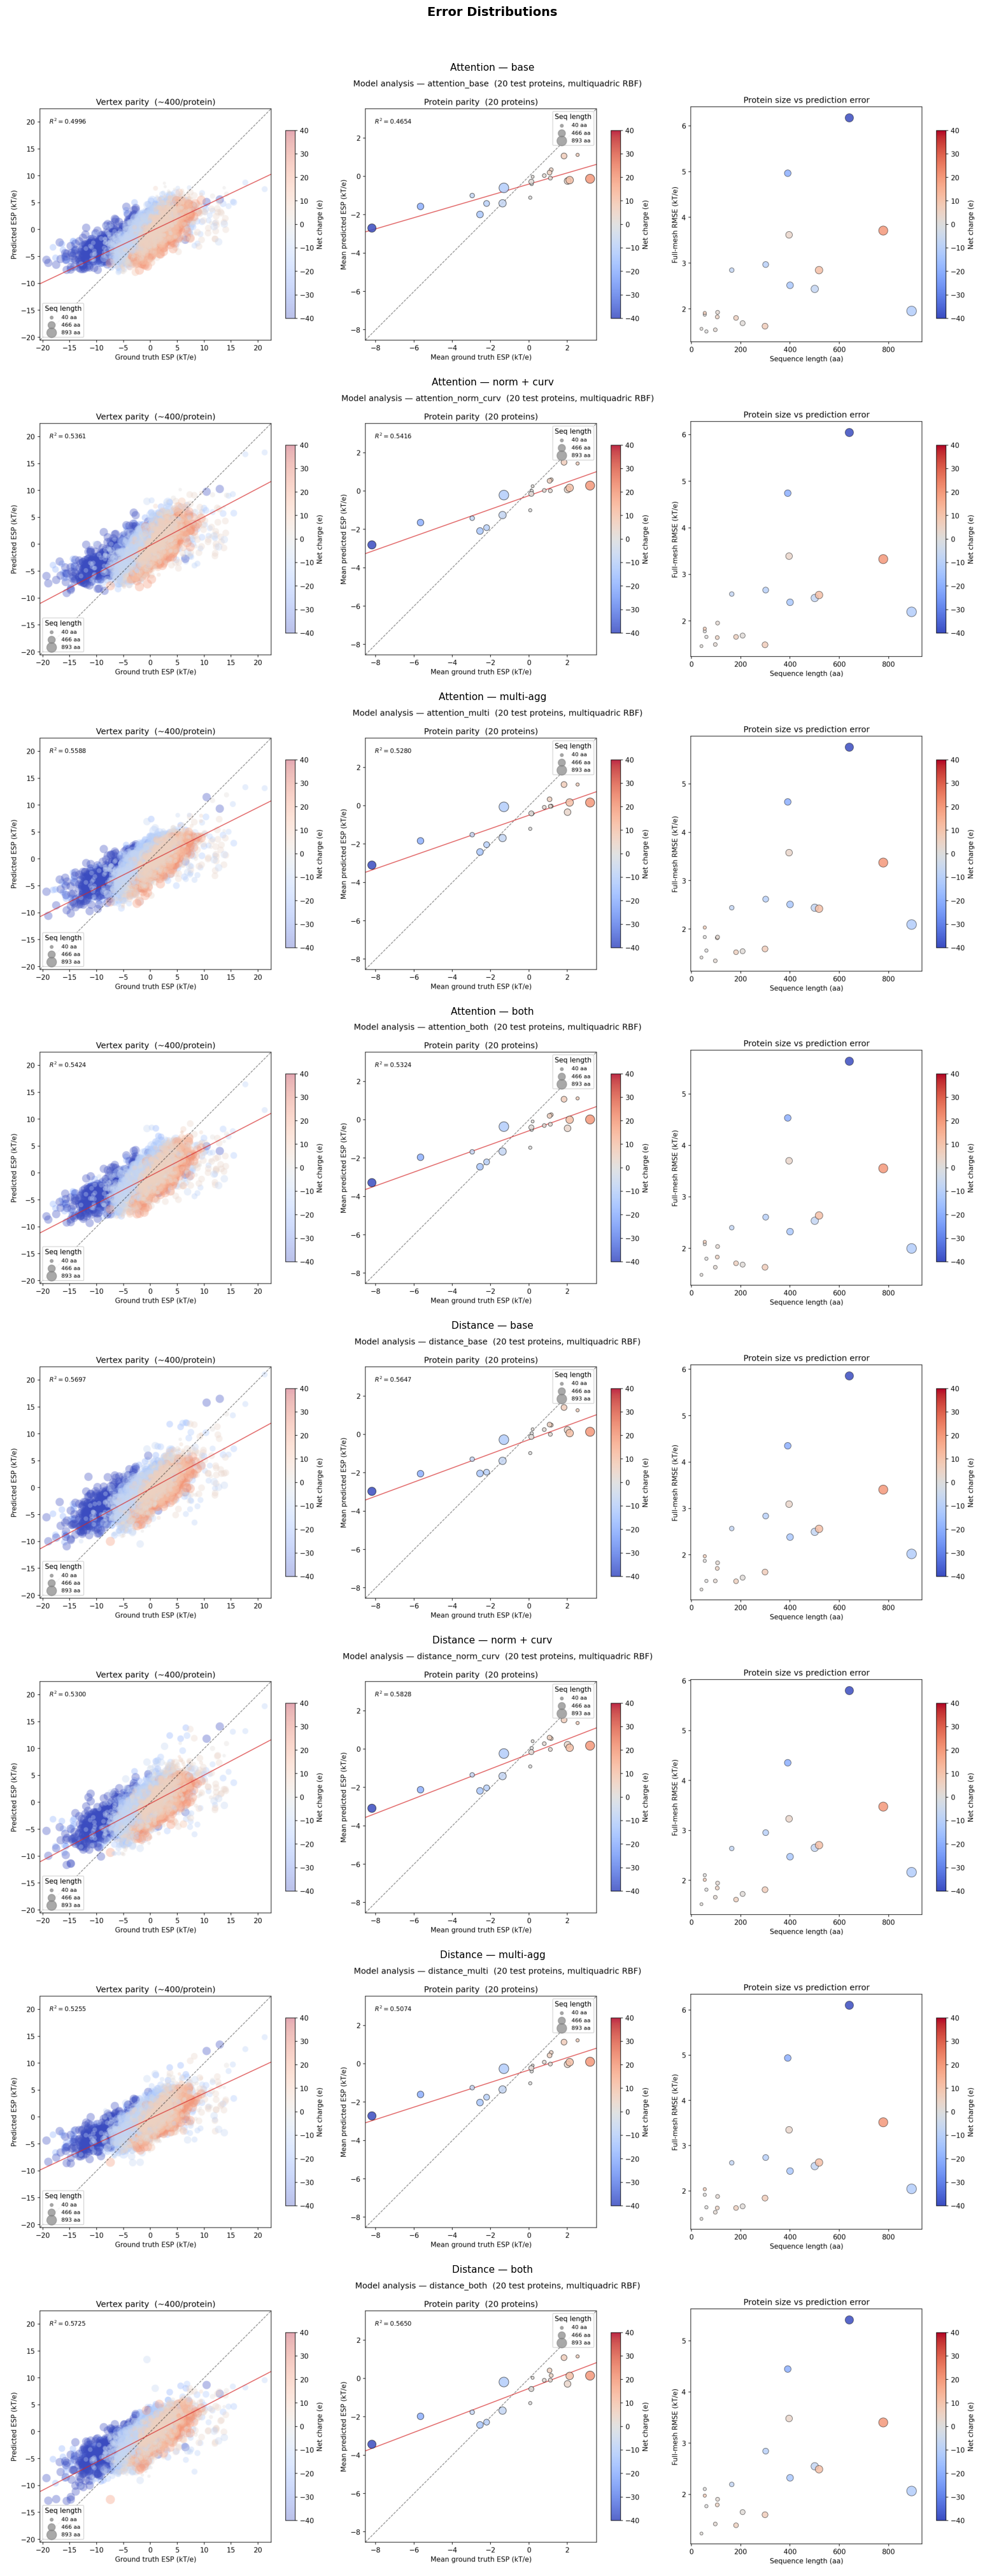

In [13]:
show_png_grid(RUNS, "error_distributions.png", "Error Distributions", ncols=1)

## 4. Metrics Comparison

Load `test_metrics.json` from each completed checkpoint directory and compare
the global sparse metrics (evaluated at query vertices only).

In [14]:
rows = []
for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows.append({
        "Run":            run["label"],
        "Model":          run["model_type"].capitalize(),
        "Features":       run["suffix"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Val loss":       g.get("loss"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

df = pd.DataFrame(rows).sort_values(["Model", "Pearson r"], ascending=[True, False])
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
display(df)

,Run,Model,Features,Pearson r,RMSE,MAE,Val loss,Train time (s),N proteins
2,Attention — multi-agg,Attention,multi,0.7868,2.9348,2.2181,0.3556,1950.8000,20
1,Attention — norm + curv,Attention,norm_curv,0.7663,3.0107,2.2777,0.3746,1858.0000,20
3,Attention — both,Attention,both,0.7655,2.9789,2.2636,0.3726,1374.2000,20
0,Attention — base,Attention,base,0.7636,3.1406,2.3779,0.4062,1170.5000,20
4,Distance — base,Distance,base,0.7761,2.9260,2.2154,0.3521,2024.3000,20
7,Distance — both,Distance,both,0.7743,2.8904,2.1899,0.3484,2021.0000,20
6,Distance — multi-agg,Distance,multi,0.7484,3.0482,2.2947,0.3866,1243.1000,20
5,Distance — norm + curv,Distance,norm_curv,0.7198,3.0076,2.2908,0.3842,2066.9000,20


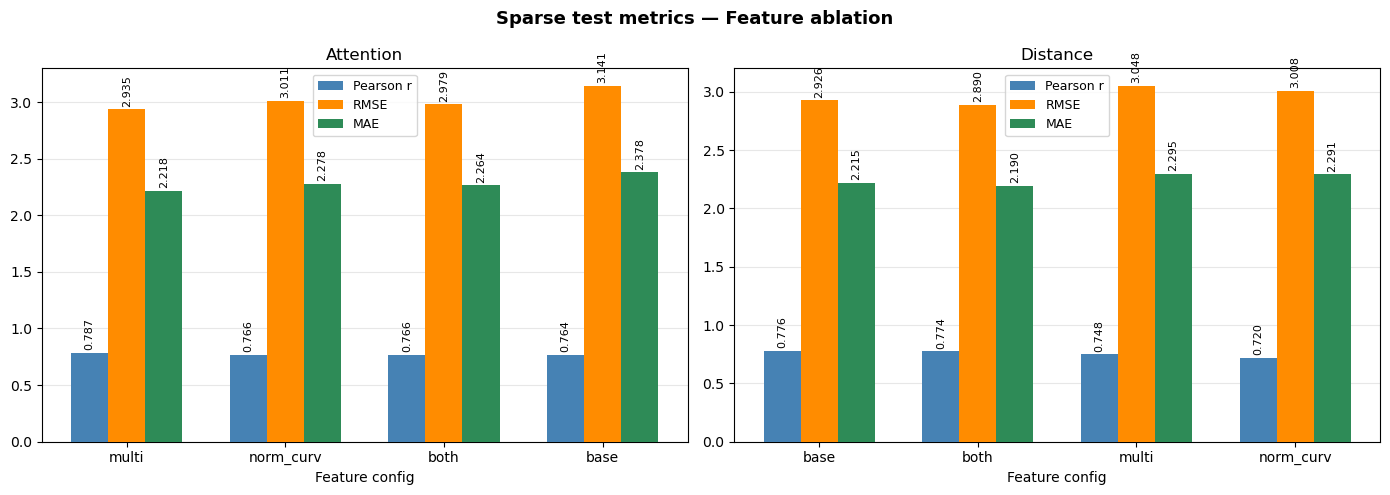

In [15]:
plot_metric_bars(df, "Sparse test metrics — Feature ablation")

### Full-mesh metrics

Same bar charts using `test_metrics_fullmesh.json` — metrics computed after RBF
reconstruction from query vertices to the complete mesh surface.

In [16]:
rows_fm = []
for run in RUNS:
    fm_path = run["ckpt_dir"] / "test_metrics_fullmesh.json"
    if not fm_path.exists():
        continue
    with open(fm_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_fm.append({
        "Run":        run["label"],
        "Model":      run["model_type"].capitalize(),
        "Features":   run["suffix"],
        "Pearson r":  g.get("pearson_r"),
        "RMSE":       g.get("rmse"),
        "MAE":        g.get("mae"),
        "N proteins": g.get("n_proteins"),
    })

df_fm = pd.DataFrame(rows_fm).sort_values(["Model", "Pearson r"], ascending=[True, False])
display(df_fm)

,Run,Model,Features,Pearson r,RMSE,MAE,N proteins
2,Attention — multi-agg,Attention,multi,0.7845,2.9574,2.2523,20
1,Attention — norm + curv,Attention,norm_curv,0.7650,3.0170,2.2950,20
3,Attention — both,Attention,both,0.7634,2.9950,2.2889,20
0,Attention — base,Attention,base,0.7623,3.1523,2.4005,20
4,Distance — base,Distance,base,0.7761,2.9360,2.2389,20
7,Distance — both,Distance,both,0.7737,2.9024,2.2140,20
6,Distance — multi-agg,Distance,multi,0.7486,3.0732,2.3287,20
5,Distance — norm + curv,Distance,norm_curv,0.7203,3.0215,2.3176,20


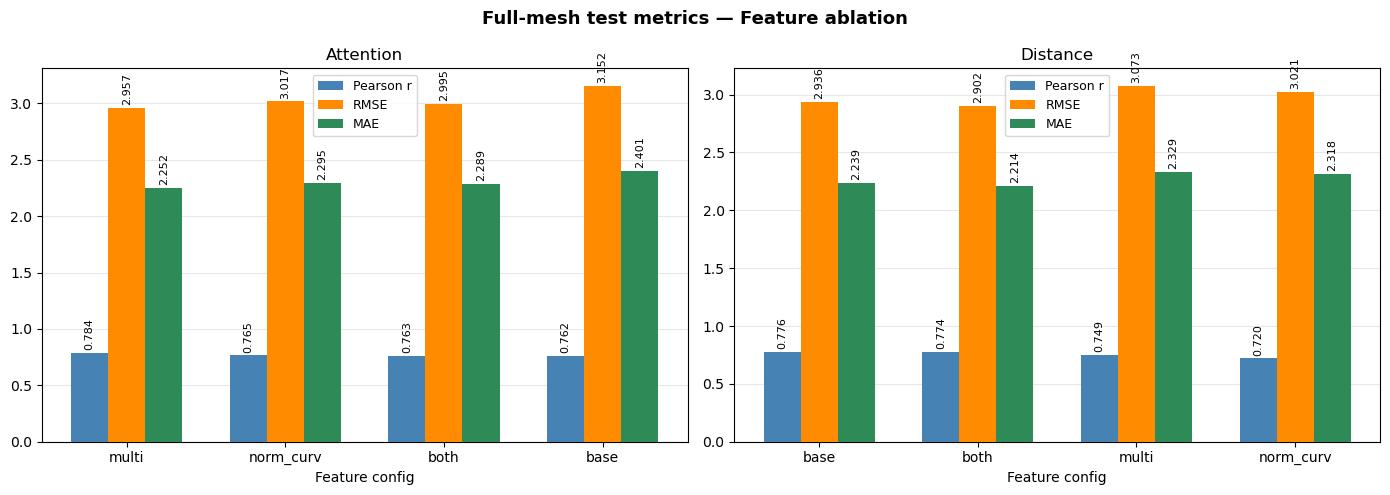

In [17]:
plot_metric_bars(df_fm, "Full-mesh test metrics — Feature ablation")

## 5. Per-protein Consistency

Loads per-protein Pearson r from all 8 runs and asks:
- Which proteins are universally easy or hard (consistent across architectures)?
- Which proteins are architecture-sensitive (high rank variance)?

**Heatmap** — proteins × runs, coloured by Pearson r. Rows sorted by mean r.

**Rank table** — for each protein, its rank within each run (1 = best), plus
mean rank and rank std across all runs.

In [18]:
import numpy as np

# ── Load per-protein Pearson r for every run that has test_metrics.json ──────
pp_data: dict[str, dict[str, float]] = {}   # {run_label: {protein_id: pearson_r}}

for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

# Build pivot: rows=proteins, cols=runs
all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

# Short protein IDs for display (strip AF- prefix and -F1 suffix)
def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]

# Short run labels (drop "Attention — " / "Distance — ")
pivot.columns = [
    label.replace("Attention — ", "Attn/").replace("Distance — ", "Dist/")
    for label in pivot.columns
]

# Sort rows by mean Pearson r (best proteins at top)
pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 20 proteins across 8 runs.


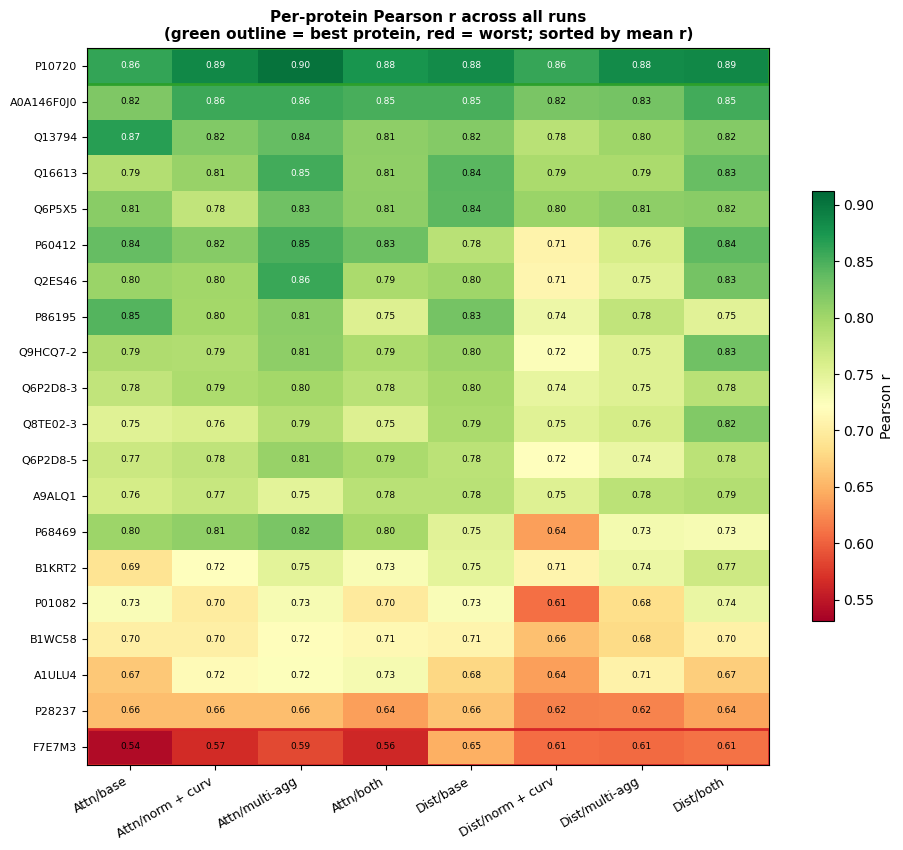

In [19]:
# ── Heatmap: proteins × runs, coloured by Pearson r ──────────────────────────
n_prot, n_runs = pivot.shape
fig, ax = plt.subplots(figsize=(max(8, n_runs * 1.2), max(6, n_prot * 0.38 + 1)))

mat = pivot.values.astype(float)
vmin = np.nanmin(mat) - 0.01
vmax = np.nanmax(mat) + 0.01

im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=vmin, vmax=vmax)

ax.set_xticks(range(n_runs))
ax.set_xticklabels(pivot.columns, fontsize=9, rotation=30, ha="right")
ax.set_yticks(range(n_prot))
ax.set_yticklabels(pivot.index, fontsize=8)

# Annotate cells
for i in range(n_prot):
    for j in range(n_runs):
        v = mat[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="black" if 0.3 < v < 0.85 else "white")

# Highlight worst and best rows
row_means = np.nanmean(mat, axis=1)
worst_idx = int(np.argmin(row_means))
best_idx  = int(np.argmax(row_means))
for idx, color in [(worst_idx, "#d62728"), (best_idx, "#2ca02c")]:
    ax.add_patch(plt.Rectangle((-0.5, idx - 0.5), n_runs, 1,
                               linewidth=2, edgecolor=color, facecolor="none"))

plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.6)
ax.set_title("Per-protein Pearson r across all runs\n"
             "(green outline = best protein, red = worst; sorted by mean r)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# ── Rank table: rank within each run (1=best), mean rank, rank std ────────────
# Rank each column independently (1 = highest Pearson r)
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print(f"Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print(f"\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print(f"\nMost architecture-sensitive proteins (highest rank std):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,Attn/base,Attn/norm + curv,Attn/multi-agg,Attn/both,Dist/base,Dist/norm + curv,Dist/multi-agg,Dist/both
P10720,0.8796,0.0141,1.1200,0.3500,2,1,1,1,1,1,1,1
A0A146F0J0,0.8419,0.0155,2.5000,1.0700,5,2,3,2,2,2,2,2
Q13794,0.8190,0.0246,4.6200,2.1300,1,3,6,4,6,5,4,8
Q16613,0.8152,0.0247,5.2500,2.1900,10,6,4,6,3,4,5,4
Q6P5X5,0.8131,0.0182,6.1200,3.1400,6,12,7,5,4,3,3,9



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,Attn/base,Attn/norm + curv,Attn/multi-agg,Attn/both,Dist/base,Dist/norm + curv,Dist/multi-agg,Dist/both
P01082,0.7014,0.0424,16.7500,1.4900,15,18,16,18,16,19,17,15
B1WC58,0.6990,0.0193,16.8800,0.9900,16,17,18,17,17,15,18,17
A1ULU4,0.6910,0.0331,16.8800,1.1300,18,16,17,15,18,17,16,18
P28237,0.6445,0.0174,18.8800,0.3500,19,19,19,19,19,18,19,19
F7E7M3,0.5905,0.0339,20.0000,0.0000,20,20,20,20,20,20,20,20



Most architecture-sensitive proteins (highest rank std):


,Mean r,Std r,Mean rank,Rank std,Attn/base,Attn/norm + curv,Attn/multi-agg,Attn/both,Dist/base,Dist/norm + curv,Dist/multi-agg,Dist/both
P68469,0.7605,0.0616,11.1200,4.5500,8,5,8,7,14,16,15,16
P60412,0.8024,0.0490,6.6200,4.1700,4,4,5,3,11,14,9,3
P86195,0.7883,0.0388,8.6200,3.8900,3,8,9,14,5,9,7,14
Q2ES46,0.7932,0.0450,7.7500,3.2400,7,7,2,8,8,12,12,6
Q6P5X5,0.8131,0.0182,6.1200,3.1400,6,12,7,5,4,3,3,9
